# Laporan Proyek Sains Data 3

## Pendahuluan

### Latar Belakang

Emas merupakan salah satu komoditas yang memiliki peran penting dalam perekonomian global. Selain digunakan sebagai alat investasi yang stabil, emas juga digunakan dalam berbagai industri, seperti perhiasan, elektronik, dan kesehatan. Fluktuasi harga emas sering kali dipengaruhi oleh berbagai faktor, termasuk kondisi pasar global, nilai tukar mata uang, tingkat inflasi, dan situasi geopolitik. Oleh karena itu, kemampuan untuk memprediksi harga emas menjadi sangat penting, terutama bagi para investor, perusahaan, dan institusi keuangan dalam mengambil keputusan strategis.

Investasi emas telah menjadi salah satu pilihan populer di Indonesia karena stabilitas nilai emas dalam jangka panjang. Untuk mendukung pengambilan keputusan dalam investasi emas, diperlukan model prediksi yang mampu memperkirakan harga emas berdasarkan data historis.

### Masalah

Fluktuasi harga emas yang dipengaruhi oleh banyak faktor sering kali membuat investor kesulitan untuk memprediksi perubahan harga emas secara akurat. Ketidaktepatan dalam memprediksi harga emas dapat menyebabkan keputusan investasi yang kurang optimal. Selain itu, tidak semua investor memiliki akses terhadap alat prediksi berbasis teknologi yang mudah digunakan. Oleh karena itu, diperlukan model prediksi yang akurat dan berbasis data yang dapat membantu investor dalam mengambil keputusan.

### Tujuan

Tujuan dari proyek ini adalah:

1. Membuat model prediksi harga emas 7 hari kedepan berdasarkan data historis.
2. Menghasilkan sebuah aplikasi sederhana yang dapat digunakan untuk memprediksi harga emas 7 hari kedepan secara real-time.



## Metodologi

### Memahami Data (Data Understanding)

#### Pengumpulan Data

Data historis emas didapatkan dari API Pluang yang terupdate secara realtime. Menggunakan data historis emas kurang lebih selama 5 tahun

##### Mengambil Data

Mendapatkan data dari link API

In [21]:
#Get data from API link
import requests
import json

url = 'https://api-pluang.pluang.com/api/v3/asset/gold/pricing?daysLimit=1825'  # Ganti dengan URL API kamu

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    print("Berhasil mengambil data. Status", response.status_code)
else:
    print("Gagal mengambil data. Status:", response.status_code)

Berhasil mengambil data. Status 200


Membersihkan data dan mengubahnya ke dalam bentuk dataframe

In [22]:
#Clean JSON data
import pandas as pd

history_df = pd.json_normalize(data['data']['history'])

new_df = history_df[['updated_at', 'sell', 'buy']]

new_df['date'] = new_df['updated_at'].str.split('T').str[0]
temp_df = new_df[['date', 'sell', 'buy']]
temp_df.head()

C:\Users\atsuga\AppData\Local\Temp\ipykernel_8288\723975748.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['date'] = new_df['updated_at'].str.split('T').str[0]


,date,sell,buy
0,2024-12-15,1491087,1453809
1,2024-12-14,1491087,1453809
2,2024-12-13,1491562,1454272
3,2024-12-12,1508511,1470798
4,2024-12-11,1494722,1457353


#### Deskripsi Data

Data saham berupa csv berisikan 1606 baris dan 3 kolom yang merupakan :

- Date : Tanggal harga emas yang berformat yyyy-mm-dd hh:mm:ss
- Sell : Harga jual emas dalam Rupiah
- Buy : Harga beli emas dalam Rupiah


Melihat tipe data dari masing masing kolom.


In [23]:
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1608 entries, 0 to 1607
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1608 non-null   object
 1   sell    1608 non-null   int64 
 2   buy     1608 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 37.8+ KB


Terbaca bahwa dari 1608 baris data tiap kolomnya tidak ada baris yang kosong (null).


#### Eksplorasi Data

Sebelum melanjutkan eksplorasi data, terlebih dahulu menjadikan kolom date atau tanggal sebagai index dari data agar memudahkan prosesnya, serta hanya menggunakan kolom sell atau harga jual karena hanya akan memprediksi harga jual emas berdasarkan data harga jual emas di hari hari sebelumnya.


In [24]:
df = temp_df
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='%Y-%m-%d').dt.date
df.set_index('date', inplace=True)
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df.tail(10)

C:\Users\atsuga\AppData\Local\Temp\ipykernel_8288\434109153.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='%Y-%m-%d').dt.date


,sell,buy
date,,
2024-12-06,1484337,1447228
2024-12-07,1483925,1446826
2024-12-08,1483925,1446826
2024-12-09,1464711,1428093
2024-12-10,1478687,1441719
2024-12-11,1494722,1457353
2024-12-12,1508511,1470798
2024-12-13,1491562,1454272
2024-12-14,1491087,1453809


Dengan menjadikan date atau tanggal sebagai index data, dapat memudahkan data untuk diplot

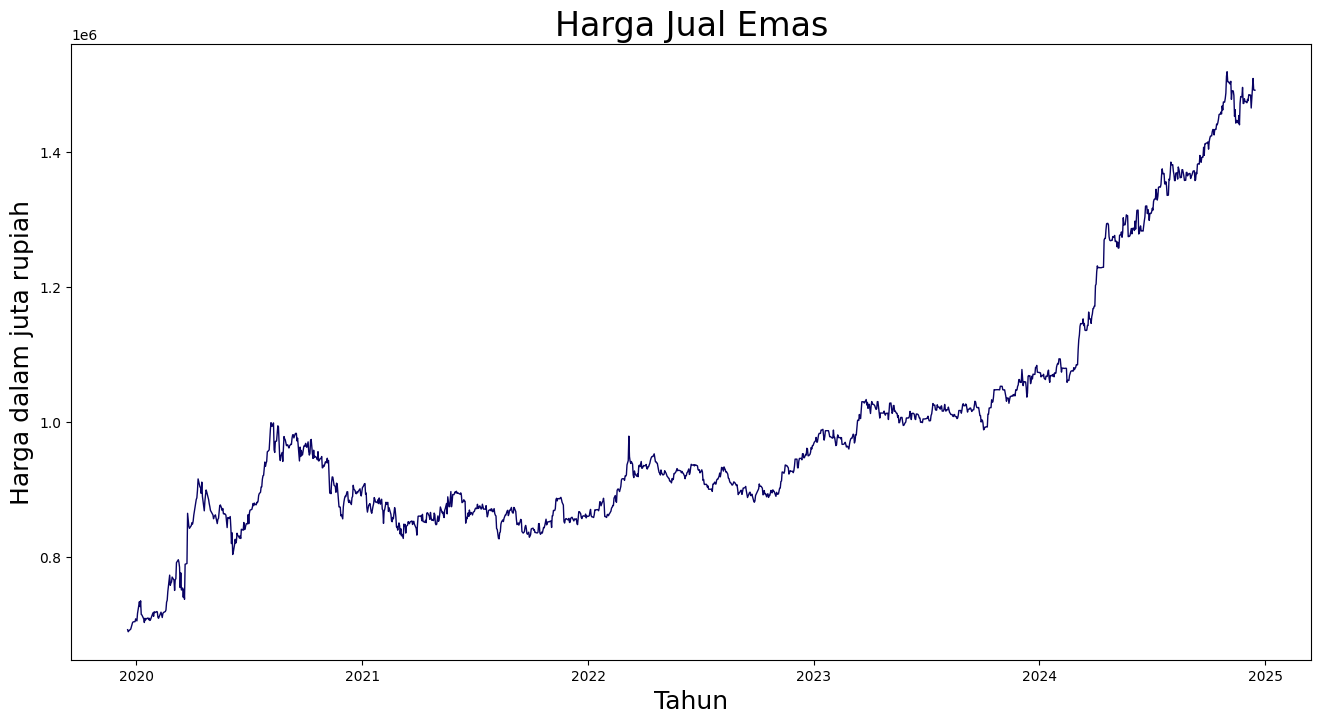

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(16, 8))
plt.title("Harga Jual Emas", fontsize=24)
plt.ylabel('Harga dalam juta rupiah', fontsize=18)
plt.xlabel('Tahun', fontsize=18)
sns.set_palette(["#090364", "#1960EF", "#EF5919"])
sns.lineplot(data=df['sell'], linewidth=1.0, dashes=False, ax=ax1)
plt.show()

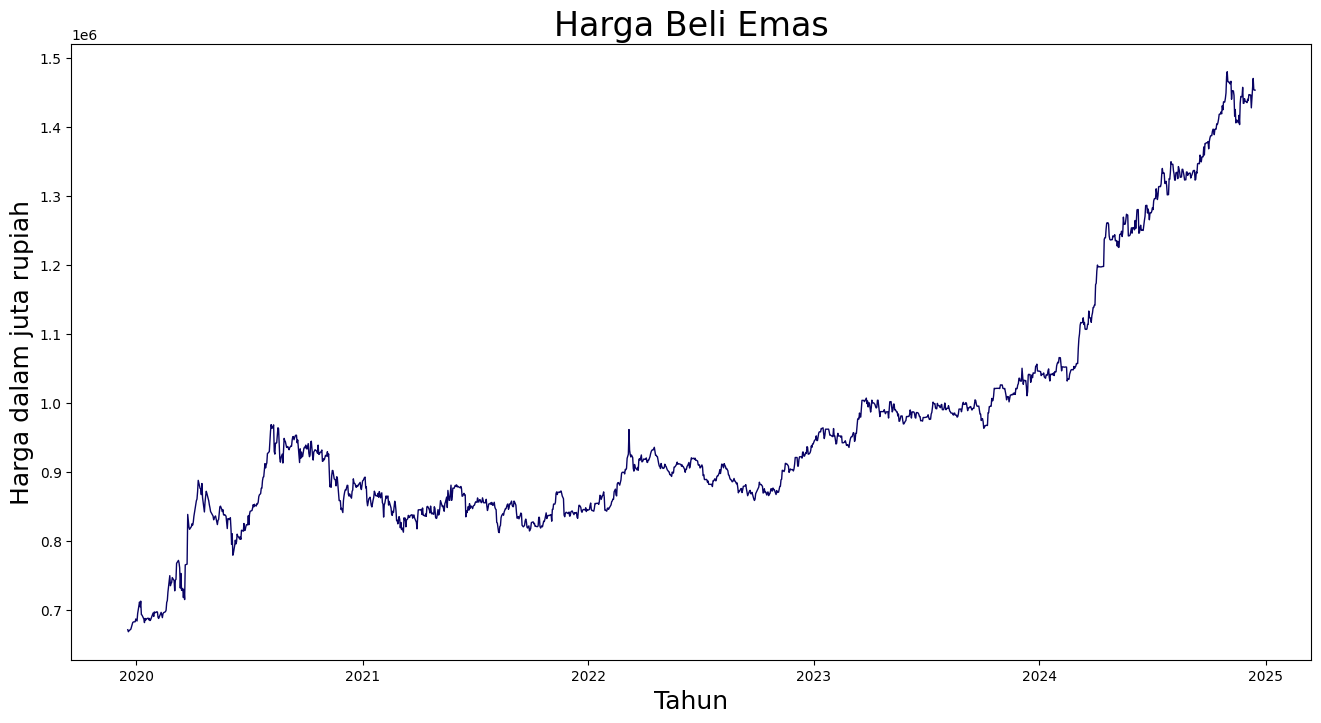

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(16, 8))
plt.title("Harga Beli Emas", fontsize=24)
plt.ylabel('Harga dalam juta rupiah', fontsize=18)
plt.xlabel('Tahun', fontsize=18)
sns.set_palette(["#090364", "#1960EF", "#EF5919"])
sns.lineplot(data=df['buy'], linewidth=1.0, dashes=False, ax=ax1)
plt.show()

Terlihat bahwa data jual emas relatif stabil dan naik dari tahun ke tahun, yang awalnya hanya berharga 800 ribuan di tahun 2020, hingga berharga kurang dari 1 juta 500 ribu diakhir tahun 2024, begitu juga dengan harga beli emas yang juga relatif stabil yang berkorelasi dengan harga jual emas. Selanjutnya melihat apakah data terdapat outlier

<Axes: >

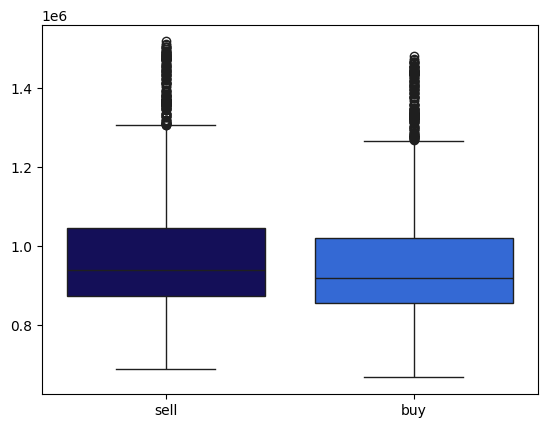

In [27]:
sns.boxplot(data=df)

Terlihat jika terdapat banyak data yang terdeksi sebagai outlier, namun data tersebut tidak akan dihilangkan atau dinormalkan karena itu bukan data error dan data asli yang akan mempengaruhi prediksi jika data tersebut diubah. Selanjutnya melihat korelasi antar kolom

       sell    buy
sell 1.0000 0.9998
buy  0.9998 1.0000


<Axes: >

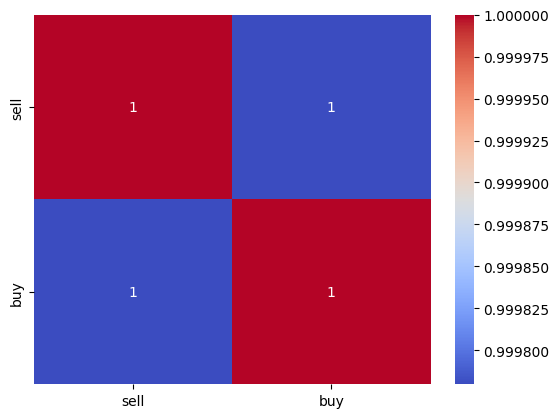

In [28]:
correlation_matrix = df.corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

Terlihat antara kolom buy dan sell memiliki nilai korelasi hampir mendekati 1 atau bahkan 1 sehingga kedua kolom digunakan untuk prediksi karena memiliki ketergantungan satu sama lain.

#### Verifikasi Kualitas Data

Dapat disimpulkan bahwa data yang digunakan terbilang bagus dan cocok untuk dipakai dalam modelling, namun perlu diperhatikan bahwa data perlu masuk ke tahap preprocessing data agar data benar benar siap untuk masuk ke tahap modelling.

### Pra-pemrosesan Data (Data Preprocessing)

#### Normalisasi Data

Melakukan scaling menggunakan Min-Max Scaling yaitu mengubah data sehingga semua nilai berada dalam rentang [0, 1] dengan rumus berikut

$$
x' = \frac{x - \text{min}(X)}{\text{max}(X) - \text{min}(X)}
$$

Di mana:

- $x'$ adalah nilai yang dinormalisasi.
- $x$ adalah nilai asli dari fitur.
- $\text{min}(X)$ adalah nilai minimum dari fitur dalam dataset.
- $\text{max}(X)$ adalah nilai maksimum dari fitur dalam dataset.

Min-Max Scaling berguna untuk meningkatkan kinerja model

In [29]:
import numpy as np

def normalize(df):
    from sklearn.preprocessing import RobustScaler, MinMaxScaler

    np_data_unscaled = np.array(df)
    scaler = MinMaxScaler()
    np_data_scaled = scaler.fit_transform(np_data_unscaled)
    print(np_data_unscaled)
    normalized_df = pd.DataFrame(np_data_scaled, columns=df.columns, index=df.index)
    pd.set_option('display.float_format', '{:.4f}'.format)  # Menampilkan 4 desimal
    return normalized_df, scaler

normalized_df, scaler = normalize(df)
normalized_df

[[ 691578  670830]
 [ 688568  667910]
 [ 689974  669274]
 ...
 [1491562 1454272]
 [1491087 1453809]
 [1491087 1453809]]


,sell,buy
date,,
2019-12-18,0.0036,0.0036
2019-12-19,0.0000,0.0000
2019-12-20,0.0017,0.0017
2019-12-23,0.0046,0.0046
2019-12-26,0.0164,0.0163
...,...,...
2024-12-11,0.9713,0.9715
2024-12-12,0.9880,0.9880
2024-12-13,0.9675,0.9677


Terlihat bahwa data hanya bernilai dari angka 0 hingga 1 setelah dinormalisasi.

#### Sliding Window

Untuk memprediksi harga emas hari esok, dibutuhkan data hari emas di hari ini, kemarin, dan 2 hari yang lalu. Sehingga dilakukan sliding window untuk menambahkan fitur atau kolom baru yang berisikan 3 hari data kemarin yang dibutuhkan untuk prediksi.

In [30]:
normalized_df

,sell,buy
date,,
2019-12-18,0.0036,0.0036
2019-12-19,0.0000,0.0000
2019-12-20,0.0017,0.0017
2019-12-23,0.0046,0.0046
2019-12-26,0.0164,0.0163
...,...,...
2024-12-11,0.9713,0.9715
2024-12-12,0.9880,0.9880
2024-12-13,0.9675,0.9677


In [31]:
import pandas as pd

def sliding_window(data, lag):
    series_sell = data['sell']
    series_buy = data['buy']
    result = pd.DataFrame()

    # Menambahkan kolom lag untuk 'sell'
    for l in lag:
        result[f'sell-{l}'] = series_sell.shift(l)
    
    # Menambahkan kolom lag untuk 'buy'
    for l in lag:
        result[f'buy-{l}'] = series_buy.shift(l)
    result

    # Menambahkan kolom 'sell' dan 'buy' asli tanpa perubahan
    result['sell'] = series_sell[l:]
    result['buy'] = series_buy[l:]
    
    # Menghapus nilai yang hilang (NaN)
    result = result.dropna()
    
    # Mengatur index sesuai dengan nilai lag
    result.index = series_sell.index[l:]
    
    return result

windowed_data = sliding_window(normalized_df, [1, 2, 3, 4, 5, 6, 7])
windowed_data = windowed_data[['sell', 'sell-1', 'sell-2', 'sell-3', 'sell-4', 'sell-5', 'sell-6', 'sell-7', 'buy', 'buy-1', 'buy-2', 'buy-3', 'buy-4', 'buy-5', 'buy-6', 'buy-7']]
print(windowed_data)


             sell  sell-1  sell-2  sell-3  sell-4  sell-5  sell-6  sell-7  \
date                                                                        
2019-12-31 0.0230  0.0180  0.0176  0.0164  0.0046  0.0017  0.0000  0.0036   
2020-01-02 0.0194  0.0230  0.0180  0.0176  0.0164  0.0046  0.0017  0.0000   
2020-01-03 0.0327  0.0194  0.0230  0.0180  0.0176  0.0164  0.0046  0.0017   
2020-01-06 0.0536  0.0327  0.0194  0.0230  0.0180  0.0176  0.0164  0.0046   
2020-01-07 0.0449  0.0536  0.0327  0.0194  0.0230  0.0180  0.0176  0.0164   
...           ...     ...     ...     ...     ...     ...     ...     ...   
2024-12-11 0.9713  0.9520  0.9352  0.9583  0.9583  0.9588  0.9589  0.9483   
2024-12-12 0.9880  0.9713  0.9520  0.9352  0.9583  0.9583  0.9588  0.9589   
2024-12-13 0.9675  0.9880  0.9713  0.9520  0.9352  0.9583  0.9583  0.9588   
2024-12-14 0.9670  0.9675  0.9880  0.9713  0.9520  0.9352  0.9583  0.9583   
2024-12-15 0.9670  0.9670  0.9675  0.9880  0.9713  0.9520  0.9352  0.9583   

#### Splitting Data

Sebelum masuk ke pemodelan, data dibagi terlebih dahulu. Data dibagi menjadi 2 yaitu 80% digunakan sebagai data train dan 20% sebagai data test. Dalam data train dan data test juga dibagi lagi menjadi data input yang berisikan data emas di 3 hari kemarin sebagai data prediksi dan data target yang merupakan data yang akan diprediksi. Hal ini dilakukan untuk mengetahui nilai error prediksi yang dihasilkan nanti.

In [32]:
def split_data(data, target, train_size):
    split_index = int(len(data) * train_size)

    x_train = data[:split_index]
    y_train = target[:split_index]
    x_test = data[split_index:]
    y_test = target[split_index:]

    return x_train, y_train, x_test, y_test

input_df = windowed_data.drop(columns=['sell', 'buy'])
target_df = windowed_data[['sell', 'buy']]

x_train, y_train, x_test, y_test = split_data(input_df, target_df, 0.8)

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1280, 14)
y_train shape: (1280, 2)
X_test shape: (321, 14)
y_test shape: (321, 2)


### Modelling

Terdapat beberapa skenario yang dilakukan untuk membandingkan nilai error yang dihasilkan dan memilih model dengan nilai error paling sedikit.

#### Regresi Linear tanpa Ensemble Bagging

##### Rumus Regresi Linear

Regresi linear dapat dinyatakan dengan rumus:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon 
$$

di mana:
- $y$ adalah variabel dependen (target).
- $\beta_0$ adalah intercept (konstanta).
- $\beta_1, \beta_2, \ldots, \beta_n$ adalah koefisien regresi untuk masing-masing variabel independen $x_1, x_2, \ldots, x_n$.
- $\epsilon$ adalah error atau residual.


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

LinearRegression()

#### Metrik Evaluasi Model

Metrik evaluasi model yang digunakan ada 3 yaitu : MSE, RMSE, dan MAPE

##### 1. MSE (Mean Squared Error)
- *Definisi*: MSE adalah rata-rata dari kuadrat selisih antara nilai yang diprediksi dan nilai aktual.
- *Rumus*:

  $
  \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
  $

  Di mana $y_i$ adalah nilai aktual, $\hat{y}_i$ adalah nilai prediksi, dan $n$ adalah jumlah data.

##### 2. RMSE (Root Mean Squared Error)
- *Definisi*: RMSE adalah akar kuadrat dari MSE, yang mengembalikan satuan ke skala yang sama dengan data asli.
- *Rumus*:

  $
  \text{RMSE} = \sqrt{\text{MSE}}
  $

##### 3. MAPE (Mean Absolute Percentage Error)
- *Definisi*: MAPE mengukur kesalahan dalam prediksi sebagai persentase dari nilai aktual.
- *Rumus*:

  $
  \text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100\%
  $

In [34]:
# Melakukan prediksi
y_pred = linear_model.predict(x_test)

# Menghitung error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Percentage Error (MAPE):", mape, " %")

Mean Squared Error (MSE): 0.00013123855848458008
Root Mean Squared Error (RMSE): 0.011455939877835431
Mean Absolute Percentage Error (MAPE): 0.010794763083647737  %


Skenario pertama dengan menggunakan model regresi linear biasa menghasilkan nilai error yang sangat kecil.

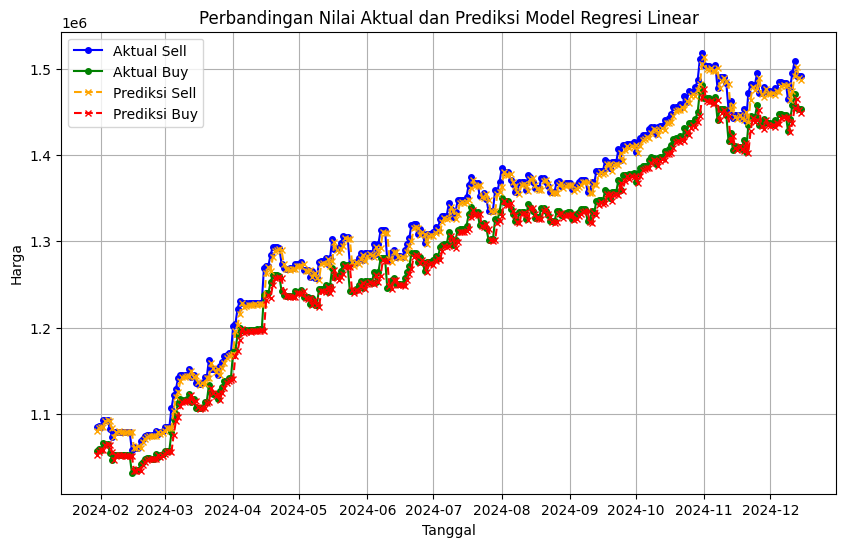

In [35]:
import matplotlib.pyplot as plt

# Membuat grafik perbandingan
plt.figure(figsize=(10, 6))

# Nilai aktual
plt.plot(
    y_test.index, 
    scaler.inverse_transform(y_test.values)[:, 0], 
    color='blue', marker='o', linestyle='-', markersize=4, label='Aktual Sell'
)
plt.plot(
    y_test.index, 
    scaler.inverse_transform(y_test.values)[:, 1], 
    color='green', marker='o', linestyle='-', markersize=4, label='Aktual Buy'
)

# Nilai prediksi
plt.plot(
    y_test.index, 
    scaler.inverse_transform(y_pred)[:, 0], 
    color='orange', marker='x', linestyle='--', markersize=4, label='Prediksi Sell'
)
plt.plot(
    y_test.index, 
    scaler.inverse_transform(y_pred)[:, 1], 
    color='red', marker='x', linestyle='--', markersize=4, label='Prediksi Buy'
)

# Menambahkan judul dan label sumbu
plt.title('Perbandingan Nilai Aktual dan Prediksi Model Regresi Linear')
plt.xlabel('Tanggal')
plt.ylabel('Harga')

# Menampilkan grid
plt.grid()

# Menambahkan legenda
plt.legend()

# Menampilkan grafik
plt.show()


In [36]:
import numpy as np

# Inisialisasi variabel untuk menyimpan prediksi
predictions = []

# Ambil data terakhir sebagai input awal
last_row = windowed_data.drop(columns=['sell', 'buy']).iloc[-1].values.reshape(1, -1)

# Iterasi untuk 7 hari ke depan
for _ in range(7):
    # Prediksi nilai untuk hari berikutnya
    predicted_value_normalized = linear_model.predict(last_row)
    predicted_value = scaler.inverse_transform(predicted_value_normalized.reshape(-1, 2))
    
    # Simpan prediksi
    predictions.append(predicted_value[0])
    
    # Update input untuk iterasi berikutnya
    new_row_normalized = np.hstack([last_row[0, 2:], predicted_value_normalized[0]])
    last_row = new_row_normalized.reshape(1, -1)

# Transformasikan prediksi menjadi DataFrame untuk visualisasi
predictions_df = pd.DataFrame(
    predictions, 
    columns=['sell', 'buy'], 
    index=pd.date_range(start=normalized_df.index[-1] + pd.Timedelta(days=1), periods=7)
)

# Harga terakhir
last_price = scaler.inverse_transform(normalized_df[['sell', 'buy']].iloc[-1].values.reshape(-1, 2))

# Hitung persentase perubahan harian
# Data pertama dihitung berdasarkan last_price
predictions_df['sell_change'] = predictions_df['sell'].pct_change() * 100
predictions_df['buy_change'] = predictions_df['buy'].pct_change() * 100

# Perubahan untuk data pertama dihitung manual
predictions_df.loc[predictions_df.index[0], 'sell_change'] = ((predictions_df['sell'].iloc[0] - last_price[0][0]) / last_price[0][0]) * 100
predictions_df.loc[predictions_df.index[0], 'buy_change'] = ((predictions_df['buy'].iloc[0] - last_price[0][1]) / last_price[0][1]) * 100

# Ganti nilai NaN untuk baris lainnya dengan 0
predictions_df['sell_change'] = predictions_df['sell_change'].fillna(0)
predictions_df['buy_change'] = predictions_df['buy_change'].fillna(0)

# Hitung perubahan total dari hari ini ke hari ketujuh
total_sell_change = ((predictions_df['sell'].iloc[-1] - last_price[0][0]) / last_price[0][0]) * 100
total_buy_change = ((predictions_df['buy'].iloc[-1] - last_price[0][1]) / last_price[0][1]) * 100

# Tampilkan hasil
print(f"Harga terakhir (Hari ini): Sell = {last_price[0][0]:.2f}, Buy = {last_price[0][1]:.2f}")
print("\nPrediksi harga untuk 7 hari ke depan:")
for date, (sell, buy, sell_change, buy_change) in predictions_df.iterrows():
    print(f"{date.strftime('%Y-%m-%d')}: Sell = {sell:.2f} ({sell_change:+.2f}%), Buy = {buy:.2f} ({buy_change:+.2f}%)")

# Tampilkan perubahan total dari hari ini ke hari ketujuh
print(f"\nPerubahan total dari hari ini ke hari ketujuh:")
print(f"Sell: {total_sell_change:+.2f}%, Buy: {total_buy_change:+.2f}%")


Harga terakhir (Hari ini): Sell = 1491087.00, Buy = 1453809.00

Prediksi harga untuk 7 hari ke depan:
2024-12-16: Sell = 1486341.76 (-0.32%), Buy = 1449195.42 (-0.32%)
2024-12-17: Sell = 1505951.38 (+1.32%), Buy = 1468245.80 (+1.31%)
2024-12-18: Sell = 1478960.62 (-1.79%), Buy = 1442247.79 (-1.77%)
2024-12-19: Sell = 1497490.76 (+1.25%), Buy = 1459678.11 (+1.21%)
2024-12-20: Sell = 1488511.56 (-0.60%), Buy = 1446394.04 (-0.91%)
2024-12-21: Sell = 1481713.69 (-0.46%), Buy = 1454009.75 (+0.53%)
2024-12-22: Sell = 1478407.56 (-0.22%), Buy = 1455502.94 (+0.10%)

Perubahan total dari hari ini ke hari ketujuh:
Sell: -0.85%, Buy: +0.12%


C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but

#### Regresi Linear dengan Ensemble Bagging

Regresi Linear dengan Ensemble Bagging adalah pendekatan yang menggabungkan model regresi linear dengan teknik ensemble bagging untuk meningkatkan akurasi prediksi dan mengurangi variabilitas model.

Dalam regresi linear dengan bagging:

1. Data Sampling:

- Dataset asli dipecah menjadi beberapa subset dengan teknik bootstrap.
- Setiap subset berukuran sama dengan dataset asli tetapi mungkin memiliki data yang berulang.

2. Model Training:

- Model regresi linear independen dilatih pada setiap subset.

3. Model Aggregation:

- Hasil prediksi dari semua model diaggregasikan dengan rata-rata (averaging) untuk menghasilkan prediksi akhir.

In [37]:
from sklearn.ensemble import BaggingRegressor
base_model = LinearRegression()
bagging_model = BaggingRegressor(estimator=base_model, n_estimators=10, bootstrap=True)
bagging_model.fit(x_train, y_train)
y_pred = bagging_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Percentage Error (MAPE): {mape} %')

Mean Squared Error: 0.00013034718669830992
Root Mean Squared Error: 0.01141696924311833
Mean Absolute Percentage Error (MAPE): 0.010720824295014201 %


Terlihat MAPE yang dihasilkan sedikit lebih kecil daripada model regresi linear biasa, sehingga terbukti bahwa ensemble bagging mungkin dapat meningkatkan akurasi prediksi.

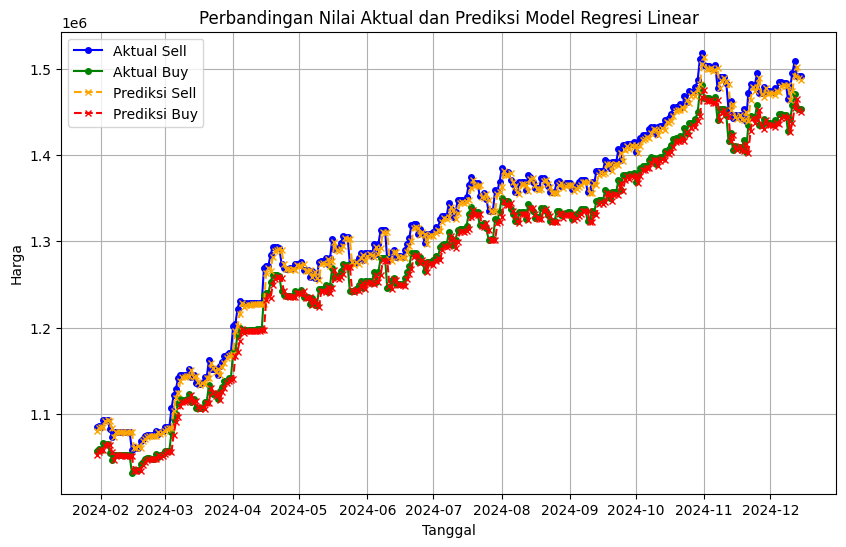

In [38]:
import matplotlib.pyplot as plt

# Membuat grafik perbandingan
plt.figure(figsize=(10, 6))

# Nilai aktual
plt.plot(
    y_test.index, 
    scaler.inverse_transform(y_test.values)[:, 0], 
    color='blue', marker='o', linestyle='-', markersize=4, label='Aktual Sell'
)
plt.plot(
    y_test.index, 
    scaler.inverse_transform(y_test.values)[:, 1], 
    color='green', marker='o', linestyle='-', markersize=4, label='Aktual Buy'
)

# Nilai prediksi
plt.plot(
    y_test.index, 
    scaler.inverse_transform(y_pred)[:, 0], 
    color='orange', marker='x', linestyle='--', markersize=4, label='Prediksi Sell'
)
plt.plot(
    y_test.index, 
    scaler.inverse_transform(y_pred)[:, 1], 
    color='red', marker='x', linestyle='--', markersize=4, label='Prediksi Buy'
)

# Menambahkan judul dan label sumbu
plt.title('Perbandingan Nilai Aktual dan Prediksi Model Regresi Linear')
plt.xlabel('Tanggal')
plt.ylabel('Harga')

# Menampilkan grid
plt.grid()

# Menambahkan legenda
plt.legend()

# Menampilkan grafik
plt.show()


In [41]:
import numpy as np

# Inisialisasi variabel untuk menyimpan prediksi
predictions = []

# Ambil data terakhir sebagai input awal
last_row = windowed_data.drop(columns=['sell', 'buy']).iloc[-1].values.reshape(1, -1)

# Iterasi untuk 7 hari ke depan
for _ in range(7):
    # Prediksi nilai untuk hari berikutnya
    predicted_value_normalized = bagging_model.predict(last_row)
    predicted_value = scaler.inverse_transform(predicted_value_normalized.reshape(-1, 2))
    
    # Simpan prediksi
    predictions.append(predicted_value[0])
    
    # Update input untuk iterasi berikutnya
    new_row_normalized = np.hstack([last_row[0, 2:], predicted_value_normalized[0]])
    last_row = new_row_normalized.reshape(1, -1)

# Transformasikan prediksi menjadi DataFrame untuk visualisasi
predictions_df = pd.DataFrame(
    predictions, 
    columns=['sell', 'buy'], 
    index=pd.date_range(start=normalized_df.index[-1] + pd.Timedelta(days=1), periods=7)
)

# Harga terakhir
last_price = scaler.inverse_transform(normalized_df[['sell', 'buy']].iloc[-1].values.reshape(-1, 2))

# Hitung persentase perubahan harian
# Data pertama dihitung berdasarkan last_price
predictions_df['sell_change'] = predictions_df['sell'].pct_change() * 100
predictions_df['buy_change'] = predictions_df['buy'].pct_change() * 100

# Perubahan untuk data pertama dihitung manual
predictions_df.loc[predictions_df.index[0], 'sell_change'] = ((predictions_df['sell'].iloc[0] - last_price[0][0]) / last_price[0][0]) * 100
predictions_df.loc[predictions_df.index[0], 'buy_change'] = ((predictions_df['buy'].iloc[0] - last_price[0][1]) / last_price[0][1]) * 100

# Ganti nilai NaN untuk baris lainnya dengan 0
predictions_df['sell_change'] = predictions_df['sell_change'].fillna(0)
predictions_df['buy_change'] = predictions_df['buy_change'].fillna(0)

# Hitung perubahan total dari hari ini ke hari ketujuh
total_sell_change = ((predictions_df['sell'].iloc[-1] - last_price[0][0]) / last_price[0][0]) * 100
total_buy_change = ((predictions_df['buy'].iloc[-1] - last_price[0][1]) / last_price[0][1]) * 100

# Tampilkan hasil
print(f"Harga terakhir (Hari ini): Sell = {last_price[0][0]:.2f}, Buy = {last_price[0][1]:.2f}")
print("\nPrediksi harga untuk 7 hari ke depan:")
for date, (sell, buy, sell_change, buy_change) in predictions_df.iterrows():
    print(f"{date.strftime('%Y-%m-%d')}: Sell = {sell:.2f} ({sell_change:+.2f}%), Buy = {buy:.2f} ({buy_change:+.2f}%)")

# Tampilkan perubahan total dari hari ini ke hari ketujuh
print(f"\nPerubahan total dari hari ini ke hari ketujuh:")
print(f"Sell: {total_sell_change:+.2f}%, Buy: {total_buy_change:+.2f}%")


Harga terakhir (Hari ini): Sell = 1491087.00, Buy = 1453809.00

Prediksi harga untuk 7 hari ke depan:
2024-12-16: Sell = 1486557.11 (-0.30%), Buy = 1449421.74 (-0.30%)
2024-12-17: Sell = 1505066.42 (+1.25%), Buy = 1467217.47 (+1.23%)
2024-12-18: Sell = 1475758.07 (-1.95%), Buy = 1439365.55 (-1.90%)
2024-12-19: Sell = 1487980.85 (+0.83%), Buy = 1450000.63 (+0.74%)
2024-12-20: Sell = 1487387.73 (-0.04%), Buy = 1445587.50 (-0.30%)
2024-12-21: Sell = 1482882.96 (-0.30%), Buy = 1452962.34 (+0.51%)
2024-12-22: Sell = 1471414.53 (-0.77%), Buy = 1444724.59 (-0.57%)

Perubahan total dari hari ini ke hari ketujuh:
Sell: -1.32%, Buy: -0.62%


C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but BaggingRegressor was fitted with feature names
  warnings.warn(
C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but BaggingRegressor was fitted with feature names
  warnings.warn(
C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but BaggingRegressor was fitted with feature names
  warnings.warn(
C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but BaggingRegressor was fitted with feature names
  warnings.warn(
C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but

### Evaluation

Dari 2 skenario yang dilakukan saat pemodelan, dapat disimpulkan bahwa menggunakan bagging belum tentu meminimalkan nilai error yang dihasilkan, terbukti bahwa error di model regresi linear biasa lebih kecil daripada model regresi linear dengan ensemble bagging, sehingga model yang dipilih untuk digunakan saat deploy adalah model regresi linear biasa.

In [42]:
import pickle

# Simpan model dan scaler
with open('model.pkl', 'wb') as model:
    pickle.dump(linear_model, model)

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

### Deployment

Project dideploy ke situs huggingface 

https://huggingface.co/spaces/atsuga/multistep